In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm
import numpy 

In [4]:
# Creating a function to  get the list of files
def get_list_of_files(dir_name):

    files_list = os.listdir(dir_name)

    return files_list


files_list_normal_train= get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/Data/train/NORMAL")
files_list_pneumonia_train = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/Data/train/PNEUMONIA")
files_list_normal_test = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/Data/test/NORMAL")
files_list_pneumonia_test = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/Data/test/PNEUMONIA")

In [5]:
print(f"Number of train samples in Normal category {len(files_list_normal_train)}")
print(f"Number of train samples in Pneumonia category {len(files_list_pneumonia_train)}")
print(f"Number of test samples in Normal category {len(files_list_normal_test)}")
print(f"Number of test samples in Pneumonia category {len(files_list_pneumonia_test)}")

Number of train samples in Normal category 1266
Number of train samples in Pneumonia category 3418
Number of test samples in Normal category 317
Number of test samples in Pneumonia category 855


# exploring and visualizing the data

(1216, 816)


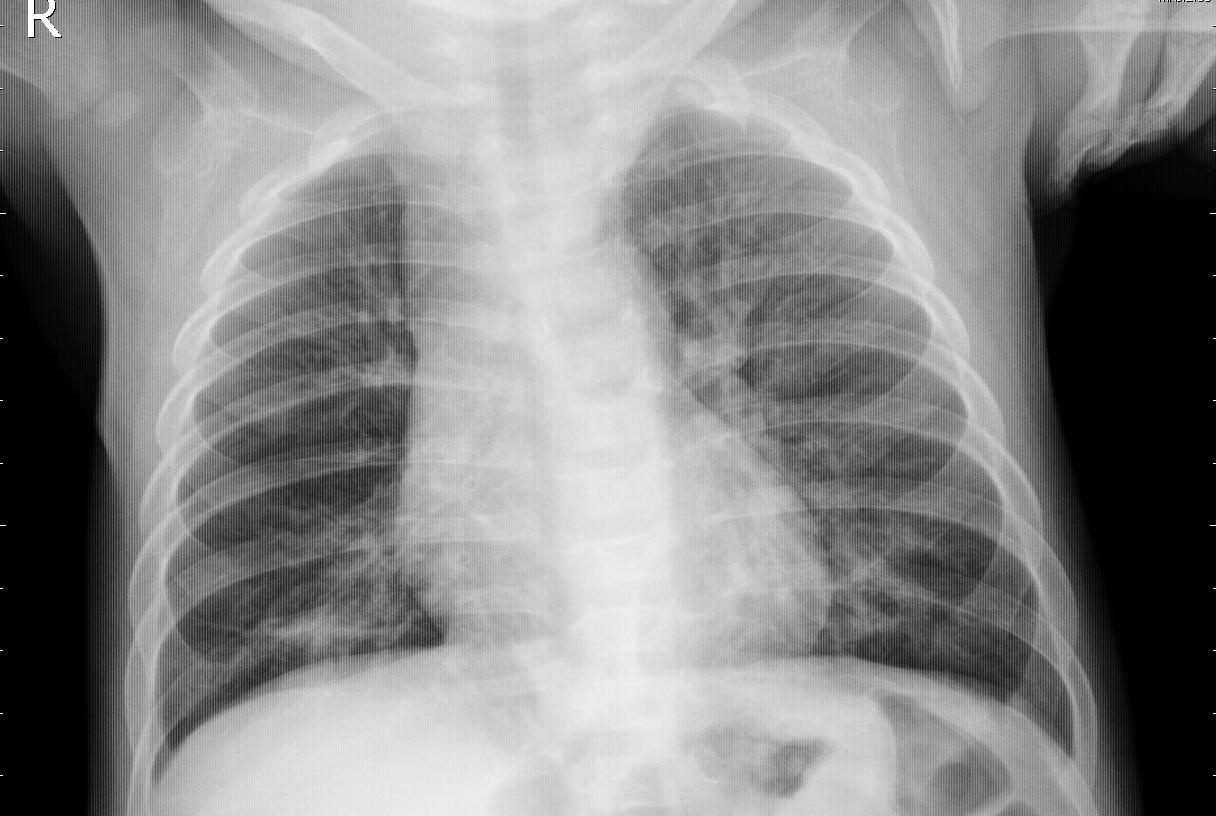

(472, 209)


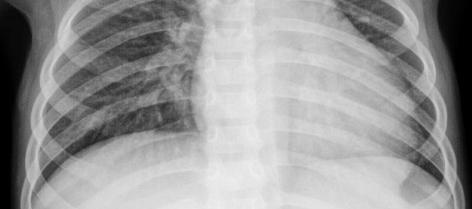

In [6]:
rand = np.random.randint(0,len(files_list_pneumonia_train),2)
for i in rand:
    path = "/Users/vinni/Desktop/ Lung Disease Detection/Data/train/PNEUMONIA/" + files_list_pneumonia_train[i]
    img = Image.open(path)
    print(img.size)
    display(img)

# as u can see , diff images have diff-diff shape so for our model we have to resize all, to the same size

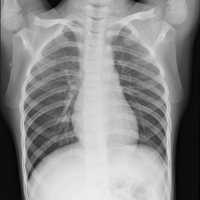

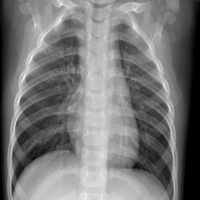

In [7]:
rand = np.random.randint(0,len(files_list_normal_train),2)
for i in rand:
    path = "/Users/vinni/Desktop/ Lung Disease Detection/Data/train/NORMAL/" + files_list_normal_train[i]
    img = Image.open(path)
    img = img.resize((200,200))
    display(img)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    # Data Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


In [7]:
data_path = "/Users/vinni/Desktop/ Lung Disease Detection/Data"
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 32, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 32, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

['NORMAL', 'PNEUMONIA']
Number of train images: 4684
Number of test images: 1170


In [11]:
class Net(nn.Module):
    def __init__(self):
        """
        Creating custom CNN architecture for Image classification
        """
        super(Net, self).__init__()
        # Input Block
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 1
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=20, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling22 = nn.MaxPool2d(2, 2)
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 2
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20) 
        )
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )
#         self.convblock6 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(10),
#         )
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
#         self.convblock8 = nn.Sequential(
#             nn.Conv2d(in_channels=10, out_channels=32, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(32)
#         )
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        self.convolution_block_out = nn.Sequential(
              nn.Conv2d(in_channels=16, out_channels=2, kernel_size=(4, 4), padding=0, bias=True),
        )
    def forward(self, x):
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
        x = self.convolution_block6(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        # Global Average pooling
        x = self.gap(x)
        x = self.convolution_block_out(x)
        x = x.view(-1, 2) # reshape 2D matrix to 1d vector
        return F.log_softmax(x, dim=-1) # binary classification

In [13]:
import torch
from torchsummary import summary

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Available processor:", device)

# Model MPS par
model = Net().to(device)

# Summary CPU par
summary(model.cpu(), input_size=(3, 224, 224)) # as summary only support the CUDA or CPU not mps

Available processor: mps
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             R

In [14]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []
def train(model, device, train_loader, optimizer, epoch):
    """
    Description: To train the model 
    
    input: model,device,train_loader,optimizer,epoch 
    
    output: loss, batch id and accuracy
    """
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
        # Initialization of gradient
        optimizer.zero_grad()
        # In PyTorch, gradient is accumulated over backprop and even though thats used in RNN generally not used in CNN
        # or specific requirements
        ## prediction on data
        y_pred = model(data)
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        train_losses.append(loss)
        # Backprop
        loss.backward()
        optimizer.step()
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
        train_acc.append(100*correct/processed)
def test(model, device, test_loader):
    """
    Description: To test the model
    
    input: model, device, test_loader
    
    output: average loss and accuracy
    
    """
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            100. * correct / len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))

In [16]:
# Defining the params for training 
model =  Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.8)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)
EPOCHS = 20
# Training the model
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 0


Loss=0.18023104965686798 Batch_id=146 Accuracy=91.63: 100%|██████████| 147/147 [00:34<00:00,  4.24it/s] 


current Learning Rate:  0.01

Test set: Average loss: 0.1807, Accuracy: 1089/1172 (92.92%)

EPOCH: 1


Loss=0.3337433338165283 Batch_id=146 Accuracy=92.14: 100%|██████████| 147/147 [00:35<00:00,  4.17it/s] 


current Learning Rate:  0.01

Test set: Average loss: 0.1481, Accuracy: 1106/1172 (94.37%)

EPOCH: 2


...

current Learning Rate:  0.00125

Test set: Average loss: 0.1109, Accuracy: 1129/1172 (96.33%)

EPOCH: 18


Loss=0.2752992808818817 Batch_id=146 Accuracy=96.48: 100%|██████████| 147/147 [00:34<00:00,  4.24it/s]  


current Learning Rate:  0.00125

Test set: Average loss: 0.1183, Accuracy: 1121/1172 (95.65%)

EPOCH: 19


Loss=0.07619943469762802 Batch_id=146 Accuracy=96.48: 100%|██████████| 147/147 [00:34<00:00,  4.28it/s] 


current Learning Rate:  0.00125

Test set: Average loss: 0.1098, Accuracy: 1121/1172 (95.65%)



Text(0.5, 1.0, 'Test Accuracy')

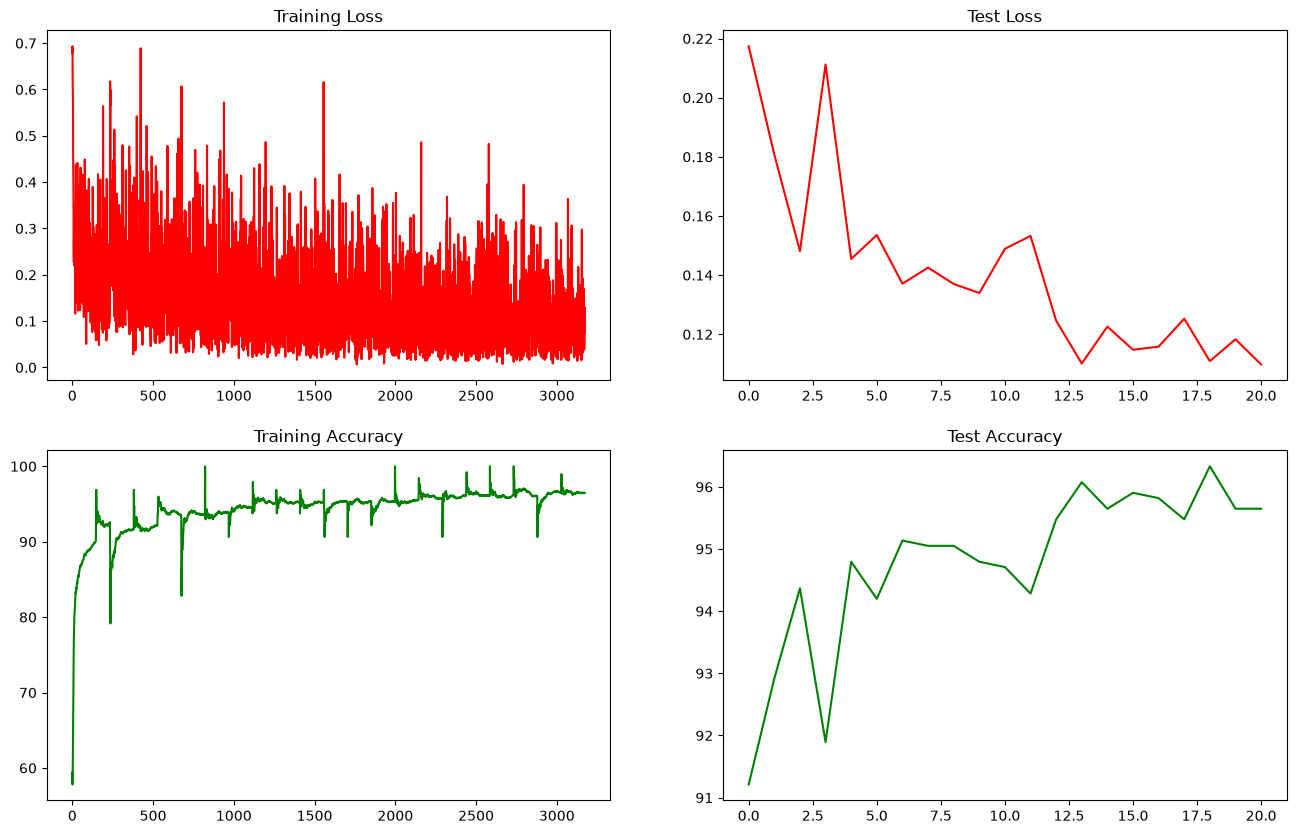

In [19]:
train_losses1 = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc1 = [i for i in train_acc]
test_losses1 = [i for i in test_losses]
test_acc1 = [i for i in test_acc]
fig, axs = plt.subplots(2,2,figsize=(16,10))
axs[0, 0].plot(train_losses1,color = "red")
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc1,color = "green")
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses1,color = "red")
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc1,color = "green")
axs[1, 1].set_title("Test Accuracy")


In [24]:
torch.save(
    model.state_dict(),
    "/Users/vinni/Desktop/ Lung Disease Detection/models/trained_model.pth"
)

In [ ]:
# checking weather the model is working properly or not
"""
import torch

model = Net()

model.load_state_dict(
    torch.load(
        "/Users/vinni/Desktop/ Lung Disease Detection/models/trained_model.pth",
        map_location=torch.device("cpu")
    )
)

model.eval() #puts the model into evaluation/inference mode


target_layer = model.convolution_block9

print(target_layer)

image_path = "/Users/vinni/Desktop/ Lung Disease Detection/Data/test/NORMAL/NORMAL(1268).jpg"

from PIL import Image

image = Image.open(image_path).convert("RGB")

image_tensor = test_transform(image)
image_tensor = image_tensor.unsqueeze(0)

output = model(image_tensor)
print(output) 

predicted_class = output.argmax(dim=1).item()
class_names = ["NORMAL", "PNEUMONIA"]
print("Prediction:", class_names[predicted_class])

confidence = output.exp().max(dim=1).values.item()
print("Confidence:", confidence * 100)"""

tensor([[-0.0475, -3.0699]], grad_fn=<LogSoftmaxBackward0>)
Prediction: NORMAL
Confidence: 95.35751342773438


In [ ]:
"""def generate_gradcam(model, image_tensor, original_image, class_names):
    
   #This is the heart of Grad-CAM
    activations = [] # What the CNN detected in the target layer during the forward pas
    gradients = [] # How important those detected features were for the final prediction

    # Target layer as, last layer is the layer which contain the import texture,shapes and edges
    target_layer = model.convolution_block9

    # Forward hook
    def forward_hook(module, input, output): # this hook stores the result of conv_9 layer as , i have told activation list store the what cnn detected in the target layer
        activations.append(output)

    # Backward hook
    def backward_hook(module, grad_input, grad_output): # This captures the gradients flowing backward through the target layer.
        gradients.append(grad_output[0])

    # Register hooks
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    # Clear previous gradients
    model.zero_grad()

    # Forward pass
    output = model(image_tensor)

    # Prediction
    predicted_class = output.argmax(dim=1).item()

    # Confidence
    confidence = output.exp().max(dim=1).values.item() # exp() -->converts log-probabilities back into normal probabilities

    # Score for predicted class
    score = output[0, predicted_class]

    # Backward pass
    score.backward()

    # Get activations and gradients
    activation = activations[0][0]
    gradient = gradients[0][0]

    # Calculate weights
    weights = gradient.mean(dim=(1, 2))

    # Create CAM
    cam = torch.zeros(19, 19)

    for i, weight in enumerate(weights):
        cam += weight * activation[i]

    # ReLU
    cam = F.relu(cam)

    # Convert to NumPy
    cam = cam.detach().numpy()

    # Normalize
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # Resize CAM
    heatmap = cv2.resize(cam, (224, 224))

    # Convert to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply color map 
    #Low importance-->Cool colors
    #High importance-->Hot colors
    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    # Original image
    original_image = np.array(
        original_image.resize((224, 224))
    )

    # Overlay
    overlay = cv2.addWeighted(
        original_image,
        0.6,
        heatmap,
        0.4,
        0
    )

    # Convert BGR → RGB
    overlay = cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )

    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()

    return (
        class_names[predicted_class],
        confidence,
        overlay
    )
    
     # calling the grad cam function
prediction, confidence, cam_image = generate_gradcam(
    model,
    image_tensor,
    image,
    class_names
)"""

In [37]:
image_path = "/Users/vinni/Desktop/ Lung Disease Detection/Data/test/NORMAL/NORMAL(1268).jpg"


image_1 = Image.open(image_path).convert("RGB")

image_tensor_1 = test_transform(image_1)
image_tensor_1 = image_tensor_1.unsqueeze(0)
prediction, confidence, cam_image = generate_gradcam(
    model,
    image_tensor_1,
    image_1,
    class_names
)

Prediction: NORMAL
Confidence: 95.35751342773438


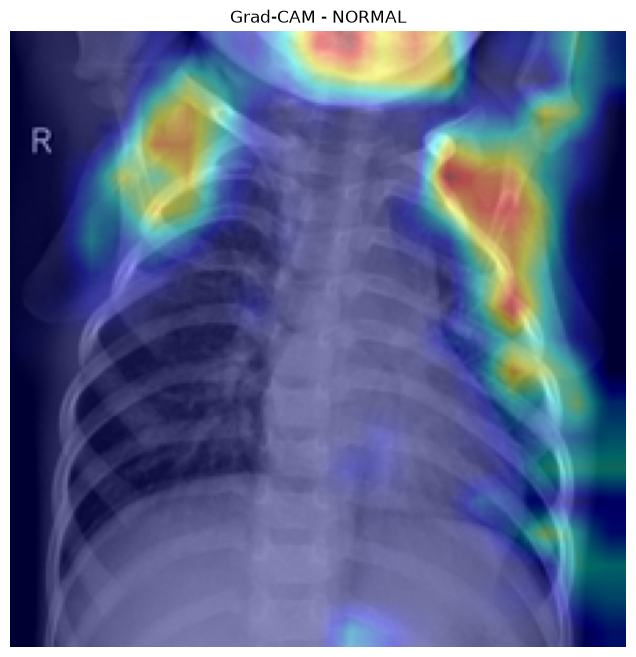

In [38]:
import matplotlib.pyplot as plt

print("Prediction:", prediction)
print("Confidence:", confidence * 100)

plt.figure(figsize=(8, 8))
plt.imshow(cam_image)
plt.axis("off")
plt.title(f"Grad-CAM - {prediction}")
plt.show()

Prediction: PNEUMONIA
Confidence: 99.66228008270264


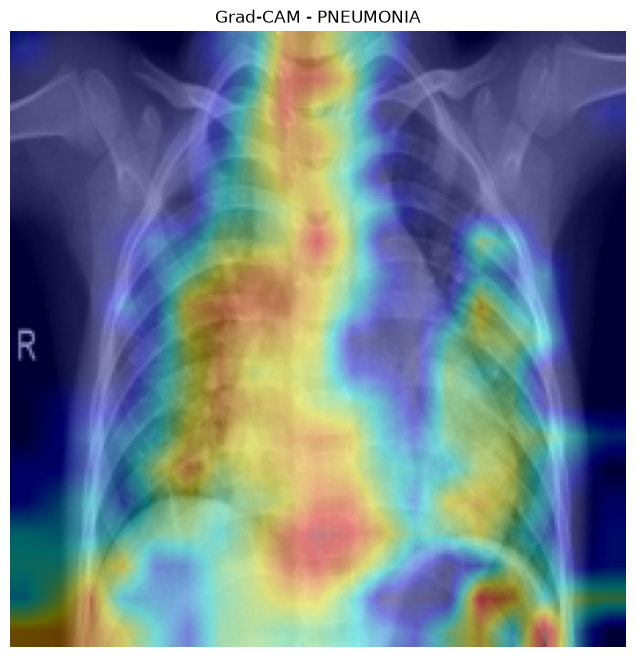

In [40]:
image_path = "/Users/vinni/Desktop/ Lung Disease Detection/Data/test/PNEUMONIA/PNEUMONIA(4267).jpg"


image_1 = Image.open(image_path).convert("RGB")

image_tensor_1 = test_transform(image_1)
image_tensor_1 = image_tensor_1.unsqueeze(0)
prediction, confidence, cam_image = generate_gradcam(
    model,
    image_tensor_1,
    image_1,
    class_names
)
import matplotlib.pyplot as plt

print("Prediction:", prediction)
print("Confidence:", confidence * 100)

plt.figure(figsize=(8, 8))
plt.imshow(cam_image)
plt.axis("off")
plt.title(f"Grad-CAM - {prediction}")
plt.show()